# Solving the Head and Neck Tumor Segmentation for MR-Guided Applications(HNTS-MRG) with UNETR

### Installing and setting up correct dependencies for the environment

In [1]:
!pip install -q "monai-weekly[nibabel, tqdm, einops]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

In [21]:
import os
import shutil
import tempfile
from glob import glob
from sklearn.model_selection import train_test_split
import numpy as np

import matplotlib.pyplot as plt
import nibabel as nib
from tqdm import tqdm

from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference
from monai.transforms import (
    AsDiscrete,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandFlipd,
    RandCropByPosNegLabeld,
    RandShiftIntensityd,
    ScaleIntensityRanged,
    Spacingd,
    RandRotate90d,
)

from monai.config import print_config
from monai.metrics import DiceMetric
from monai.networks.nets import UNETR

from monai.data import (
    DataLoader,
    Dataset,
    CacheDataset,
    load_decathlon_datalist,
    decollate_batch,
)


import torch

print_config()

MONAI version: 1.5.dev2513
Numpy version: 1.26.4
Pytorch version: 2.4.1+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: ef083a32ccc13ee3937a4bd8acc12b9cdc174e18
MONAI __file__: /home/<username>/.local/lib/python3.10/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.2
scikit-image version: 0.21.0
scipy version: 1.8.0
Pillow version: 9.0.1
Tensorboard version: 2.16.2
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.19.1+cu121
tqdm version: 4.66.4
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 1.3.5
einops version: 0.8.1
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing

### Setting up directories for training

Project is set up to access dataset stored at the Cybele lab at NTNU.

In [3]:
directory = "data_directory"
os.makedirs(directory, exist_ok=True)
root_dir = directory

# Define the correct training directory path
base_directory = "/datasets/tdt4265/mic/open/HNTS-MRG"

print(f"Base directory path: {base_directory}")
print(f"Base directory exists: {os.path.exists(base_directory)}")

Base directory path: /datasets/tdt4265/mic/open/HNTS-MRG
Base directory exists: True


### Hyperparameters

In [4]:
train_validation_split = 0.8

In [5]:
# Sort patients into a list in accending order
train_patients = sorted(glob(os.path.join(base_directory, "train", "[0-9]*")), key=lambda x: int(os.path.basename(x)))
test_patients = sorted(glob(os.path.join(base_directory, "test", "[0-9]*")), key=lambda x: int(os.path.basename(x)))

# Organize patients into dictionaries with image and corresponding label for each patient
train_files = []
for patient in train_patients:
    train_files.append({"image": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_T2.nii.gz")), "label": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_mask.nii.gz"))})
test_files = []
for patient in test_patients:
    test_files.append({"image": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_T2.nii.gz")), "label": glob(os.path.join(patient, "preRT", "[0-9]*_preRT_mask.nii.gz"))})

# Split training into train and validation data
train_files, val_files = train_test_split(train_files, test_size=train_validation_split)

### Inspect images

Inspecting images to determine intensity values of the T2-weighted scans as these are not standardized in MR-scans.

In [46]:
samples = glob(os.path.join(base_directory, "train", "[0-9]*", "preRT", "[0-9]*_preRT_T2.nii.gz"))

min_intensities = []
max_intensities = []
mean_intensities = []
std_intensities = []
p1_intensities = []
p99_intensities = []

for sample in samples:
    img = nib.load(sample)
    data = img.get_fdata()

    min_intensities.append(data.min())
    max_intensities.append(data.max())
    mean_intensities.append(data.mean())
    std_intensities.append(data.std())
    p1_intensities.append(np.percentile(data, 1))
    p99_intensities.append(np.percentile(data, 99))

print(max(p99_intensities))
print(min(p1_intensities))

2571.5341796875
0.0


Using 1st and 99th percentiles to accurately capture intensities while also eliminating outliers from faulty scans.

### Transforms

Defining transformations for train and validation datasets

In [22]:
# Initial transforms for both training and validation datasets
pre_cache_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys="image", a_min=0.0, a_max=2572.0, b_min=0.0, b_max=1.0, clip=True), #Using values found above
    CropForegroundd(keys=["image", "label"], source_key="image"),
])

# Random data augmentation for train dataset
post_cache_train_transforms = Compose([
    RandCropByPosNegLabeld(keys=["image", "label"], label_key="label", spatial_size=(64, 64, 32), pos=1, neg=1, num_samples=4, image_key="image", image_threshold=0),
    RandFlipd(keys=["image", "label"], spatial_axis=[0], prob=0.10),
    RandFlipd(keys=["image", "label"], spatial_axis=[1], prob=0.10),
    RandFlipd(keys=["image", "label"], spatial_axis=[2], prob=0.10),
    RandRotate90d(keys=["image", "label"], prob=0.10, max_k=3),
    RandShiftIntensityd(keys="image", offsets=0.10, prob=0.50)
])

/home/hermaos/.local/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


### Set up cache and dataloader

In [ ]:
train_cache = CacheDataset(
    data=train_files,
    transform=pre_cache_transforms,
    cache_rate=1.0,
    num_workers=18, #24 threads available on Cybele computers
)

val_cache = CacheDataset(
    data=val_files,
    transform=pre_cache_transforms,
    cache_rate=1.0,
    num_workers=18, #Caching between train and val done in series, not at the same time
)

# Apply random transformations at access time
random_train_cache = Dataset(
    data=train_cache,
    transform=post_cache_train_transforms
)

train_loader = DataLoader(
    dataset=random_train_cache,
    batch_size=1,
    shuffle=True,
    num_workers=18,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_cache,
    batch_size=1,
    shuffle=False,
    num_workers=18,
    pin_memory=True
)


Loading dataset: 100%|██████████| 104/104 [00:25<00:00,  4.15it/s]

Sample 0: image shape = torch.Size([1, 171, 171, 86]), label shape = torch.Size([1, 171, 171, 86])
Sample 1: image shape = torch.Size([1, 171, 171, 85]), label shape = torch.Size([1, 171, 171, 85])
Sample 2: image shape = torch.Size([1, 306, 179, 66]), label shape = torch.Size([1, 306, 179, 66])
Sample 3: image shape = torch.Size([1, 171, 171, 73]), label shape = torch.Size([1, 171, 171, 73])
Sample 4: image shape = torch.Size([1, 338, 179, 72]), label shape = torch.Size([1, 338, 179, 72])


### Checking transformations and dataloader by visualizing an image

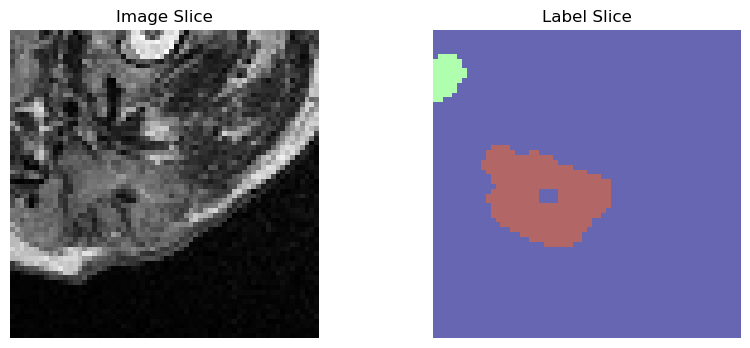

In [33]:
# Get a single scan after transformations
scan = next(iter(train_loader))

# Access image and label in scan
image = scan["image"]  # Shape: [B, C, H, W, D] for 3D images
label = scan["label"]  # Same shape as image, or [B, 1, H, W, D] if single-channel

# [B, C, H, W, D] → [H, W, D]
image_np = image[0][0].detach().cpu().numpy()
label_np = label[0][0].detach().cpu().numpy()

# Pick a central slice
slice_idx = image_np.shape[2] // 2
image_slice = image_np[:, :, slice_idx]
label_slice = label_np[:, :, slice_idx]

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_slice, cmap="gray")
plt.title("Image Slice")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(label_slice, cmap="jet", alpha=0.6)
plt.title("Label Slice")
plt.axis("off")
plt.show()

### Defining model, optimizer and loss function

In [ ]:
# TODO: Store hyperparameters in code block above instead
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNETR(
    in_channels=1,
    out_channels=3,
    img_size=(64, 64, 32),
    feature_size=16,
    hidden_size=768,
    mlp_dim=3072,
    num_heads=12,
    proj_type="perceptron",
    norm_name="instance",
    res_block=True,
    dropout_rate=0.0,
).to(device)

loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
torch.backends.cudnn.benchmark = True
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)